## Spiking Neural Networks for MNIST Training

Spiking Neural Networks (SNNs) are a new generation of neural networks that mimic the brain's information processing closer than traditional Artificial Neural Networks (ANNs). Instead of real-valued activations, SNNs communicate and compute using discrete events called 'spikes'.

For this task, we will use the `snnTorch` library, which is built on PyTorch and provides a flexible framework for constructing and training SNNs.

In [23]:
%pip install snntorch matplotlib numpy pandas jupyter

Note: you may need to restart the kernel to use updated packages.


In [24]:
# Install snnTorch if you haven't already


# Import necessary libraries
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
# from snntorch import utils # Removed as per recommendation's traceback

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
# import numpy as np # Removed as per recommendation's traceback
from torch.optim import lr_scheduler

# Set device to GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [25]:
import numpy as np
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)


In [26]:
class FakeQuantSTE(torch.autograd.Function):
    """
    Forward: quantize to a FIXED scale (round + clamp).
    Backward: straight-through estimator — gradient passes through unchanged.
    """
    @staticmethod
    def forward(ctx, x, num_bits, signed, scale):
        if signed:
            qmin, qmax = -(2**(num_bits - 1)), (2**(num_bits - 1) - 1)
        else:
            qmin, qmax = 0, (2**num_bits - 1)
        x_q = torch.clamp(torch.round(x / scale), qmin, qmax)
        return x_q * scale

    @staticmethod
    def backward(ctx, grad_output):
        # No gradient needed for num_bits, signed, scale — only x is learnable.
        return grad_output, None, None, None


def fake_quant(x, num_bits=4, signed=True, fixed_range=None):
    """
    fixed_range: the FIXED max magnitude defining the quantization grid.

    - Weights:           pass fixed_range=None  → scale derived from weight
                         abs().max() each forward pass. Safe because weights
                         are frozen within a pass and change slowly across steps.
    - Membrane potential: pass fixed_range=3*threshold  → static grid anchored
                         to the firing threshold so the same integer value always
                         means the same voltage. FPGA-realistic.
    - Activations (cur): pass fixed_range via EMA buffer (see QuantizedNet) →
                         static per-layer scale that freezes at eval time,
                         matching what an FPGA would use after calibration.
    """
    if signed:
        qmax = (2**(num_bits - 1) - 1)
    else:
        qmax = (2**num_bits - 1)

    if fixed_range is not None:
        x_max = fixed_range
    else:
        x_max = x.detach().abs().max().clamp(min=1e-8)

    scale = x_max / qmax
    return FakeQuantSTE.apply(x, num_bits, signed, scale)


## 1. Load and Preprocess MNIST Dataset

We will download the MNIST dataset, which consists of 28x28 grayscale images of handwritten digits. We'll apply `transforms.ToTensor()` to convert the PIL images to PyTorch tensors and normalize them within the range [0, 1].

In [27]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.Compose([
    transforms.ToTensor() # Removed Normalize for rate encoding
])

# Download and load the MNIST training dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Download and load the MNIST test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 60000
Test dataset size: 10000


## 2. Create DataLoaders

We'll use PyTorch's `DataLoader` to efficiently load batches of data, shuffle the training set, and parallelize data loading.

In [28]:
batch_size = 128

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 469
Number of test batches: 79


## 3. Define the Spiking Neural Network (SNN) Architecture

We will build a simple feedforward SNN using `snntorch.Leaky` neurons. The network will consist of an input layer, a hidden layer, and an output layer. We'll flatten the 28x28 MNIST images to a 784-dimensional vector.

## 3. Define the Spiking Neural Network (SNN) Architecture

The `QuantizedNet` class below is the single network definition used for all experiments.
It supports both LIF (beta < 1) and IF (beta = 1) neuron types via the `beta` parameter, and can run in fp32 baseline mode or quantized mode via the `weight_bits`/`act_bits`/`mem_bits` flags.

**EMA calibration** (`ema_momentum=0.01`) tracks the running max of `cur1` and `cur2` during training and freezes those ranges at eval time — this is the FPGA-realistic approach: the quantization grid for activations is a static constant baked in at deployment, not computed on the fly from each batch.

In [29]:
class QuantizedNet(nn.Module):
    """
    Two-layer fully-connected SNN supporting LIF (beta < 1) and IF (beta = 1).

    Quantization flags
    ------------------
    weight_bits / act_bits / mem_bits : int or None
        Bit widths for weights, pre-synaptic currents, and membrane potentials.
        Set all to None for fp32 baseline (no fake-quant applied anywhere).

    EMA activation calibration
    --------------------------
    cur1_range / cur2_range are exponential-moving-average buffers that track
    the running max of the pre-synaptic currents during training.  They freeze
    at net.eval(), giving a static activation scale — exactly what an FPGA
    uses after post-training calibration.  This replaces the old
    fixed_range=None approach that was re-deriving scale from each batch,
    causing an unstable, shifting quantization grid.

    ema_momentum : float
        Controls how fast the EMA tracks new batches (default 0.01 ≈ slow,
        stable tracking).  Lower = smoother but slower to converge on true range.
    """

    def __init__(self, num_inputs, num_hidden, num_outputs, beta, num_steps,
                 threshold=1.0,
                 weight_bits=None, act_bits=None, mem_bits=None,
                 ema_momentum=0.01):
        super().__init__()

        self.num_inputs   = num_inputs
        self.num_hidden   = num_hidden
        self.num_outputs  = num_outputs
        self.beta         = beta
        self.num_steps    = num_steps
        self.threshold    = threshold
        self.weight_bits  = weight_bits
        self.act_bits     = act_bits
        self.mem_bits     = mem_bits
        self.ema_momentum = ema_momentum

        spike_grad = surrogate.fast_sigmoid(slope=10)
        # bias=False: saves LUTs on FPGA (no adder tree for bias accumulation)
        self.fc1  = nn.Linear(num_inputs,  num_hidden,  bias=False)
        self.lif1 = snn.Leaky(beta=self.beta, spike_grad=spike_grad,
                               reset_mechanism='subtract', threshold=self.threshold)
        self.fc2  = nn.Linear(num_hidden,  num_outputs, bias=False)
        self.lif2 = snn.Leaky(beta=self.beta, spike_grad=spike_grad,
                               reset_mechanism='subtract', threshold=self.threshold)

        # EMA buffers for activation ranges (not learnable parameters).
        # Initialised to 1.0 — will be updated during the first training steps.
        # These correspond to the static scale constants that would be baked
        # into the FPGA bitstream after calibration.
        self.register_buffer('cur1_range', torch.tensor(1.0))
        self.register_buffer('cur2_range', torch.tensor(1.0))

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
    def _qw(self, w):
        """Quantize a weight tensor (dynamic scale from weight's own range)."""
        if self.weight_bits is None:
            return w
        return fake_quant(w, num_bits=self.weight_bits, signed=True, fixed_range=None)

    def _qa(self, x, buf_name):
        """
        Quantize a pre-synaptic current using the EMA-calibrated static range.

        During training  : update the EMA buffer, then quantize with the
                           *updated* range so the grid tracks the signal.
        During eval      : buffer is frozen — identical to what the FPGA uses.
        """
        if self.act_bits is None:
            return x
        cur_max = x.detach().abs().max().clamp(min=1e-8)
        if self.training:
            # Exponential moving average update (in-place on the buffer)
            buf = getattr(self, buf_name)
            buf.mul_(1.0 - self.ema_momentum).add_(cur_max * self.ema_momentum)
        fixed = getattr(self, buf_name).item()
        return fake_quant(x, num_bits=self.act_bits, signed=True, fixed_range=fixed)

    def _qm(self, mem):
        """
        Quantize membrane potential with a static range anchored to threshold.

        fixed_range = 3 * threshold rationale:
          - With reset_mechanism='subtract', membrane can transiently reach up
            to ~2x threshold right before reset.
          - 3x gives one extra threshold of headroom for overshoot, keeping the
            spiking decision boundary well inside the representable range rather
            than at its edge.
        """
        if self.mem_bits is None:
            return mem
        return fake_quant(mem, num_bits=self.mem_bits, signed=True,
                          fixed_range=3.0 * self.threshold)

    # ------------------------------------------------------------------
    # Forward pass
    # ------------------------------------------------------------------
    def forward(self, x_timeseries):
        # x_timeseries: (num_steps, batch_size, num_inputs)
        mem1 = torch.zeros(x_timeseries.size(1), self.num_hidden,  device=x_timeseries.device)
        mem2 = torch.zeros(x_timeseries.size(1), self.num_outputs, device=x_timeseries.device)

        spk_rec = []
        mem_rec = []

        # Quantize weights once per forward pass (they're frozen within a pass).
        # Re-derived every call so the grid tracks weight drift across training steps.
        w1_q = self._qw(self.fc1.weight)
        w2_q = self._qw(self.fc2.weight)

        for step in range(self.num_steps):
            current_input = x_timeseries[step]   # (batch_size, num_inputs)

            cur1 = torch.nn.functional.linear(current_input, w1_q, self.fc1.bias)
            cur1 = self._qa(cur1, 'cur1_range')   # EMA-calibrated static scale

            spk1, mem1 = self.lif1(cur1, mem1)
            mem1 = self._qm(mem1)                 # 3×threshold static range

            cur2 = torch.nn.functional.linear(spk1, w2_q, self.fc2.bias)
            cur2 = self._qa(cur2, 'cur2_range')   # EMA-calibrated static scale

            spk2, mem2 = self.lif2(cur2, mem2)
            mem2 = self._qm(mem2)                 # 3×threshold static range

            spk_rec.append(spk2)
            mem_rec.append(mem2)

        spk_rec = torch.stack(spk_rec)  # (num_steps, batch_size, num_outputs)
        mem_rec = torch.stack(mem_rec)
        return spk_rec, mem_rec


# ── Instantiate LIF network ────────────────────────────────────────────────
num_inputs  = 784   # 28×28 MNIST images flattened
num_outputs = 10    # digits 0-9
num_hidden  = 128   # reduced for FPGA BRAM budget
num_steps   = 20    # simulation timesteps (lower = less FPGA latency)
beta        = 0.875   # LIF decay rate
lif_threshold = 0.5

# To run the fp32 baseline: leave all bit-width args at None (default).
# To run the quantized version: pass e.g. weight_bits=4, act_bits=4, mem_bits=4.
net = QuantizedNet(
    num_inputs, num_hidden, num_outputs, beta, num_steps,
    threshold=lif_threshold,
    weight_bits=8, act_bits= None, mem_bits=None
).to(device)

print(f"SNN Architecture:\n{net}")
print(f"LIF threshold: {net.lif1.threshold}  |  beta: {net.beta}")
print(f"Quantization: W={net.weight_bits}-bit  A={net.act_bits}-bit  Mem={net.mem_bits}-bit")


SNN Architecture:
QuantizedNet(
  (fc1): Linear(in_features=784, out_features=128, bias=False)
  (lif1): Leaky()
  (fc2): Linear(in_features=128, out_features=10, bias=False)
  (lif2): Leaky()
)
LIF threshold: 0.5  |  beta: 0.875
Quantization: W=8-bit  A=None-bit  Mem=None-bit


## 4. Training Setup

We'll define the hyperparameters for training, including the number of epochs, learning rate, loss function, and optimizer. For SNNs, a common loss function is `functional.ce_rate_loss` from `snntorch` for rate-coded outputs.

In [30]:
# Training hyperparameters
num_epochs = 10
learning_rate = 5e-4 # Adjusted learning rate

# Loss and Optimizer
loss_fn = SF.ce_rate_loss()
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, betas=(0.9, 0.999))
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_loader) * num_epochs) # Added scheduler
clip_grad_norm_value = 1.0 # Gradient clipping value

# Accuracy metric
def accuracy_score(outputs, labels):
    _, predicted = outputs.max(1)
    correct = (predicted == labels).sum().item()
    return correct / labels.size(0)

In [31]:
print(net.fc1.weight[0][:5])

tensor([ 0.0273,  0.0296, -0.0084,  0.0328, -0.0078], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [32]:
print(fake_quant(net.fc1.weight[0][:5]))

tensor([ 0.0281,  0.0281, -0.0094,  0.0328, -0.0094], device='cuda:0',
       grad_fn=<FakeQuantSTEBackward>)


## 5. Training Loop

Now we'll implement the training loop. For each epoch, we iterate through the training data, perform a forward pass, calculate the loss based on the firing rate of the output neurons, and update the model parameters via backpropagation.

In [33]:
loss_hist = []
train_acc_hist = []
val_acc_hist = []

best_acc = 0.0 # CHANGE 3: Initialize best accuracy tracker
print("Beginning Training...")

# Training loop
for epoch in range(num_epochs):
    running_loss = 0
    running_correct = 0

    total_spikes = 0 # CHANGE 4: Initialize total spikes counter

    net.train() # Set network to training mode

    for i, (images, labels) in enumerate(train_loader):
        images = images.view(-1, num_inputs).to(device)
        labels = labels.to(device)

        # Generate spike trains from static images
        spike_input = snn.spikegen.rate(images, num_steps=num_steps, gain=2.0) # Increased gain

        # Forward pass with spike train input
        spk_rec, mem_rec = net(spike_input)

        # CHANGE 4: Accumulate spikes across the batch for sparsity tracking
        total_spikes += spk_rec.sum().item()

        # Calculate loss (using output spike rate)
        loss = loss_fn(spk_rec, labels)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), clip_grad_norm_value)
        optimizer.step()
        scheduler.step() # Step the scheduler

        running_loss += loss.item()
        # CHANGE 7: Compute output rates explicitly
        output_rates = spk_rec.sum(dim=0)
        running_correct += accuracy_score(output_rates, labels) * labels.size(0)

    # Calculate training metrics
    avg_loss = running_loss / len(train_loader)
    train_acc = running_correct / len(train_dataset) # Renamed to train_acc

    # CHANGE 4: Calculate spike sparsity per image
    avg_spikes_per_image = total_spikes / len(train_dataset)

    loss_hist.append(avg_loss)
    train_acc_hist.append(train_acc)

    # CHANGE 2: Validation loop added after every epoch
    net.eval() # Set network to evaluation mode
    val_correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(-1, num_inputs).to(device)
            labels = labels.to(device)

            spike_input = snn.spikegen.rate(images, num_steps=num_steps, gain=2.0) # Increased gain
            spk_rec, mem_rec = net(spike_input)

            output_rates = spk_rec.sum(dim=0)
            _, predicted = output_rates.max(1)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / len(test_dataset)
    val_acc_hist.append(val_acc)

    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Avg Spikes/Img: {avg_spikes_per_image:.1f}")

    # CHANGE 3: Checkpoint the best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(net.state_dict(), "best_lif_model.pth")
        print(f"  --> New best model saved! (Val Acc: {best_acc:.4f})")

print("Training complete!")

Beginning Training...
Epoch 1/10 | Loss: 1.5900 | Train Acc: 0.8896 | Val Acc: 0.9402 | Avg Spikes/Img: 24.5
  --> New best model saved! (Val Acc: 0.9402)
Epoch 2/10 | Loss: 1.5150 | Train Acc: 0.9504 | Val Acc: 0.9571 | Avg Spikes/Img: 22.4
  --> New best model saved! (Val Acc: 0.9571)
Epoch 3/10 | Loss: 1.5018 | Train Acc: 0.9613 | Val Acc: 0.9611 | Avg Spikes/Img: 21.9
  --> New best model saved! (Val Acc: 0.9611)
Epoch 4/10 | Loss: 1.4946 | Train Acc: 0.9677 | Val Acc: 0.9659 | Avg Spikes/Img: 21.6
  --> New best model saved! (Val Acc: 0.9659)
Epoch 5/10 | Loss: 1.4895 | Train Acc: 0.9732 | Val Acc: 0.9675 | Avg Spikes/Img: 21.4
  --> New best model saved! (Val Acc: 0.9675)
Epoch 6/10 | Loss: 1.4861 | Train Acc: 0.9766 | Val Acc: 0.9675 | Avg Spikes/Img: 21.2
Epoch 7/10 | Loss: 1.4835 | Train Acc: 0.9788 | Val Acc: 0.9684 | Avg Spikes/Img: 21.0
  --> New best model saved! (Val Acc: 0.9684)
Epoch 8/10 | Loss: 1.4818 | Train Acc: 0.9800 | Val Acc: 0.9693 | Avg Spikes/Img: 21.0
  --> 

## 6. Evaluate Model Performance

Finally, we'll evaluate the trained SNN on the test dataset to measure its generalization performance.

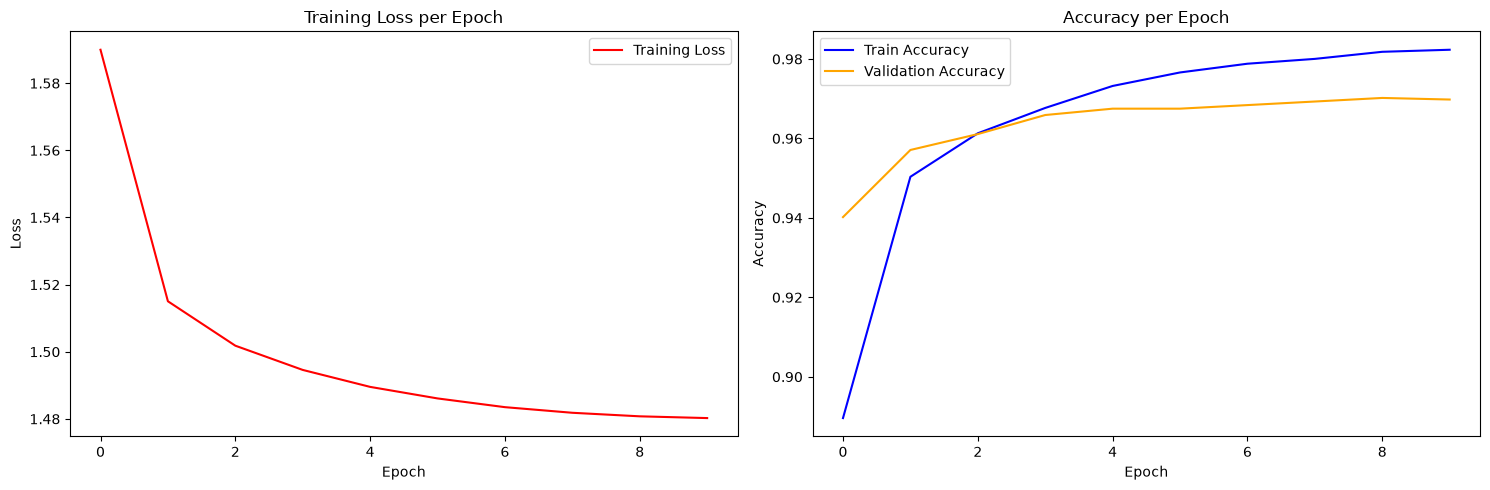

In [34]:
# ==========================================
# 5. Plotting Results
# ==========================================
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(loss_hist, label="Training Loss", color="red")
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label="Train Accuracy", color="blue")
plt.plot(val_acc_hist, label="Validation Accuracy", color="orange")
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 7. Integrate-and-Fire (IF) Model Training

Now, let's configure and train an Integrate-and-Fire (IF) model. An IF neuron is a special case of a Leaky Integrate-and-Fire (LIF) neuron where the `beta` parameter (decay rate) is set to `1.0`, meaning there is no membrane potential decay between spikes. We'll use the same architecture and training setup, but with `beta=1.0`, and track its performance separately.

In [35]:
# Network parameters for IF Model (beta = 1.0)
# An IF neuron is a LIF with beta=1: no membrane decay between timesteps.
# Using the same QuantizedNet class with beta=1.0 is the standard snntorch approach.
if_beta      = 1.0
if_threshold = 0.5  # matched to LIF for a fair comparison

net_if = QuantizedNet(
    num_inputs, num_hidden, num_outputs, if_beta, num_steps,
    threshold=if_threshold,
    weight_bits=8, act_bits=None, mem_bits=None
).to(device)

print(f"IF SNN Architecture (beta={if_beta}):\n{net_if}")
print(f"IF threshold: {net_if.lif1.threshold}  |  beta: {net_if.beta}")
print(f"Quantization: W={net_if.weight_bits}-bit  A={net_if.act_bits}-bit  Mem={net_if.mem_bits}-bit")


IF SNN Architecture (beta=1.0):
QuantizedNet(
  (fc1): Linear(in_features=784, out_features=128, bias=False)
  (lif1): Leaky()
  (fc2): Linear(in_features=128, out_features=10, bias=False)
  (lif2): Leaky()
)
IF threshold: 0.5  |  beta: 1.0
Quantization: W=8-bit  A=None-bit  Mem=None-bit


In [36]:
# Training setup for IF Model

# Separate history lists for IF model
if_loss_hist = []
if_train_acc_hist = []
if_val_acc_hist = []

if_best_acc = 0.0 # Initialize best accuracy tracker for IF model

# Optimizer and scheduler for IF model parameters
if_optimizer = torch.optim.Adam(net_if.parameters(), lr=learning_rate, betas=(0.9, 0.999))
if_scheduler = lr_scheduler.CosineAnnealingLR(if_optimizer, T_max=len(train_loader) * num_epochs)

print("Beginning IF Model Training...")

Beginning IF Model Training...


In [37]:
# Training loop for IF Model
for epoch in range(num_epochs):
    running_loss_if = 0
    running_correct_if = 0
    total_spikes_if = 0

    net_if.train() # Set IF network to training mode

    for i, (images, labels) in enumerate(train_loader):
        images = images.view(-1, num_inputs).to(device)
        labels = labels.to(device)

        spike_input = snn.spikegen.rate(images, num_steps=num_steps, gain=2.0) # Increased gain

        spk_rec_if, mem_rec_if = net_if(spike_input)

        total_spikes_if += spk_rec_if.sum().item()

        loss_if = loss_fn(spk_rec_if, labels)

        if_optimizer.zero_grad()
        loss_if.backward()
        torch.nn.utils.clip_grad_norm_(net_if.parameters(), clip_grad_norm_value)
        if_optimizer.step()
        if_scheduler.step()

        running_loss_if += loss_if.item()
        output_rates_if = spk_rec_if.sum(dim=0)
        running_correct_if += accuracy_score(output_rates_if, labels) * labels.size(0)

    avg_loss_if = running_loss_if / len(train_loader)
    train_acc_if = running_correct_if / len(train_dataset)
    avg_spikes_per_image_if = total_spikes_if / len(train_dataset)

    if_loss_hist.append(avg_loss_if)
    if_train_acc_hist.append(train_acc_if)

    net_if.eval() # Set IF network to evaluation mode
    val_correct_if = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(-1, num_inputs).to(device)
            labels = labels.to(device)

            spike_input = snn.spikegen.rate(images, num_steps=num_steps, gain=2.0) # Increased gain
            spk_rec_if, mem_rec_if = net_if(spike_input)

            output_rates_if = spk_rec_if.sum(dim=0)
            _, predicted_if = output_rates_if.max(1)
            val_correct_if += (predicted_if == labels).sum().item()

    val_acc_if = val_correct_if / len(test_dataset)
    if_val_acc_hist.append(val_acc_if)

    print(f"Epoch {epoch+1}/{num_epochs} (IF) | Loss: {avg_loss_if:.4f} | Train Acc: {train_acc_if:.4f} | Val Acc: {val_acc_if:.4f} | Avg Spikes/Img: {avg_spikes_per_image_if:.1f}")

    if val_acc_if > if_best_acc:
        if_best_acc = val_acc_if
        torch.save(net_if.state_dict(), "best_if_model.pth")
        print(f"  --> New best IF model saved! (Val Acc: {if_best_acc:.4f})")

print("IF Model Training complete!")

Epoch 1/10 (IF) | Loss: 1.5843 | Train Acc: 0.8992 | Val Acc: 0.9470 | Avg Spikes/Img: 23.9
  --> New best IF model saved! (Val Acc: 0.9470)
Epoch 2/10 (IF) | Loss: 1.5145 | Train Acc: 0.9548 | Val Acc: 0.9614 | Avg Spikes/Img: 22.2
  --> New best IF model saved! (Val Acc: 0.9614)
Epoch 3/10 (IF) | Loss: 1.5010 | Train Acc: 0.9649 | Val Acc: 0.9662 | Avg Spikes/Img: 21.7
  --> New best IF model saved! (Val Acc: 0.9662)
Epoch 4/10 (IF) | Loss: 1.4932 | Train Acc: 0.9715 | Val Acc: 0.9679 | Avg Spikes/Img: 21.4
  --> New best IF model saved! (Val Acc: 0.9679)
Epoch 5/10 (IF) | Loss: 1.4884 | Train Acc: 0.9766 | Val Acc: 0.9698 | Avg Spikes/Img: 21.1
  --> New best IF model saved! (Val Acc: 0.9698)
Epoch 6/10 (IF) | Loss: 1.4845 | Train Acc: 0.9798 | Val Acc: 0.9728 | Avg Spikes/Img: 21.0
  --> New best IF model saved! (Val Acc: 0.9728)
Epoch 7/10 (IF) | Loss: 1.4819 | Train Acc: 0.9826 | Val Acc: 0.9740 | Avg Spikes/Img: 20.9
  --> New best IF model saved! (Val Acc: 0.9740)
Epoch 8/10 (I

## 8. Plotting Results for IF Model

Let's visualize the training loss and accuracy for the Integrate-and-Fire (IF) model.

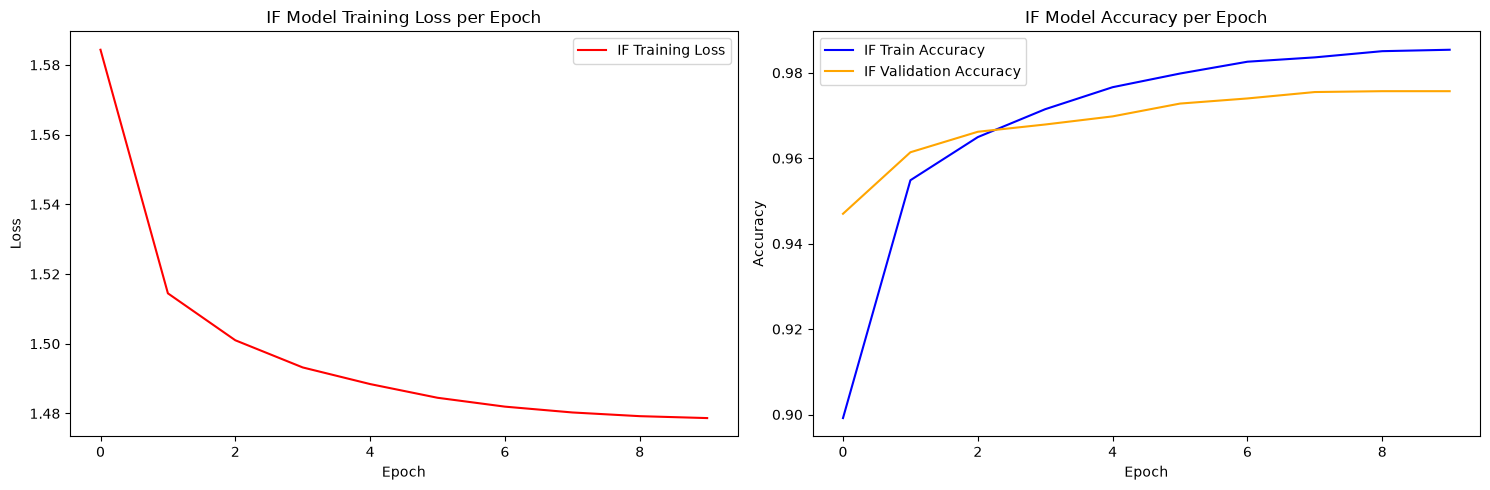

In [38]:
# ==========================================
# Plotting Results for IF Model
# ==========================================
plt.figure(figsize=(15, 5))

# Plot Loss for IF Model
plt.subplot(1, 2, 1)
plt.plot(if_loss_hist, label="IF Training Loss", color="red")
plt.title('IF Model Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracies for IF Model
plt.subplot(1, 2, 2)
plt.plot(if_train_acc_hist, label="IF Train Accuracy", color="blue")
plt.plot(if_val_acc_hist, label="IF Validation Accuracy", color="orange")
plt.title('IF Model Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


, , ,,,,## 9. Comparative Plotting (LIF vs IF)

Finally, let's compare the performance of the LIF and IF models side-by-side.

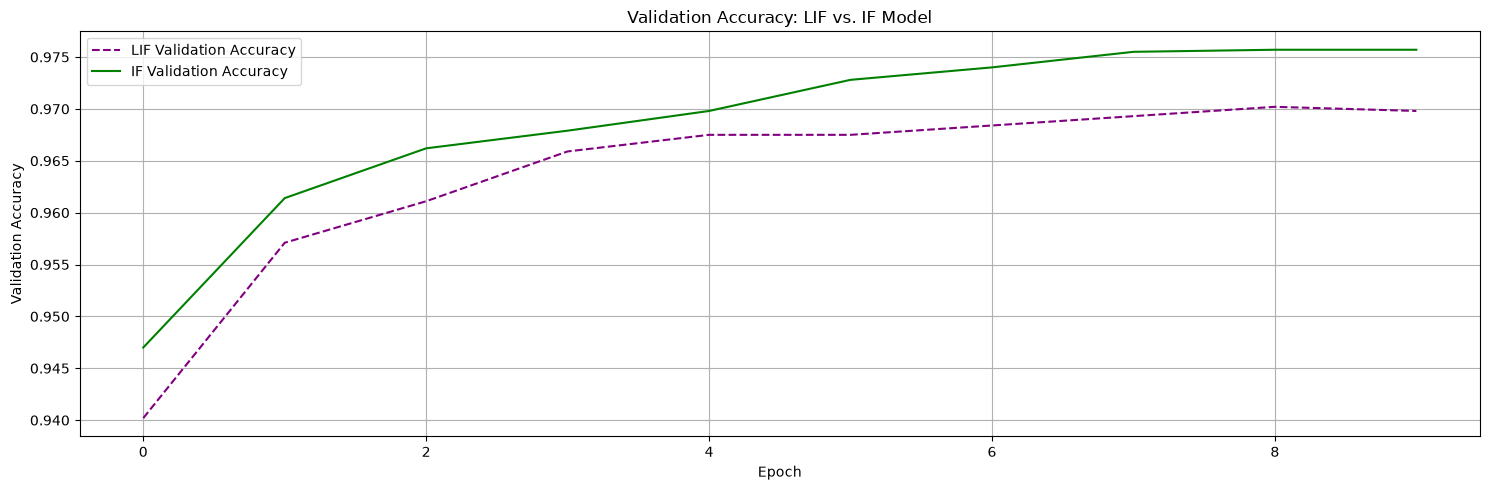

In [39]:
# ==========================================
# Comparative Plotting (LIF vs IF)
# ==========================================
plt.figure(figsize=(15, 5))

# Plot Validation Accuracies
plt.subplot(1, 1, 1)
plt.plot(val_acc_hist, label="LIF Validation Accuracy", color="purple", linestyle='--')
plt.plot(if_val_acc_hist, label="IF Validation Accuracy", color="green", linestyle='-')
plt.title('Validation Accuracy: LIF vs. IF Model')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [40]:
# import os
# import torch
# import shutil

# # Make a dedicated folder for LIF
# os.makedirs("mem_lif", exist_ok=True)

# def export_weights_banked_interleaved(weight_tensor, prefix, num_bits=8, num_banks=8):
#     scale = weight_tensor.detach().abs().max() / (2**(num_bits-1) - 1)
#     w_int = torch.clamp(
#         torch.round(weight_tensor.detach() / scale),
#         -(2**(num_bits-1)),
#         (2**(num_bits-1) - 1)
#     ).to(torch.int8).cpu().numpy()

#     for bank in range(num_banks):
#         bank_rows = w_int[bank::num_banks, :]
#         with open(f"mem_lif/{prefix}_bank{bank}.mem", 'w') as f:
#             for val in bank_rows.flatten():
#                 f.write(f'{int(val) & 0xFF:02X}\n')

#     print(f"Exported {prefix}: {w_int.shape} → {num_banks} banks (INTERLEAVED)")

# # 1. EXPLICITLY LOAD THE BEST LIF WEIGHTS
# # This guarantees we are exporting the fully trained model, not random garbage
# try:
#     net.load_state_dict(torch.load("best_lif_model.pth", weights_only=True))
#     print("✅ Loaded best_lif_model.pth successfully.")
# except Exception as e:
#     print(f"⚠️ Warning: best_lif_model.pth not found. Error: {e}")

# net.eval() # Lock in the network

# # 2. Export both layers
# export_weights_banked_interleaved(net.fc1.weight, "fc1_weights", num_bits=8, num_banks=8)
# export_weights_banked_interleaved(net.fc2.weight, "fc2_weights", num_bits=8, num_banks=8)

# # 3. Zip for download
# shutil.make_archive("mem_files_lif", "zip", "mem_lif")
# print("\n🎉 Done — download mem_files_lif.zip from the Colab file browser!") 

In [41]:
# import os
# import torch
# import shutil

# # Make a dedicated folder for IF baseline to keep it separate from LIF
# os.makedirs("mem_if", exist_ok=True)

# def export_weights_banked_interleaved(weight_tensor, prefix, num_bits=8, num_banks=8):
#     scale = weight_tensor.detach().abs().max() / (2**(num_bits-1) - 1)
#     w_int = torch.clamp(
#         torch.round(weight_tensor.detach() / scale),
#         -(2**(num_bits-1)),
#         (2**(num_bits-1) - 1)
#     ).to(torch.int8).cpu().numpy()

#     for bank in range(num_banks):
#         bank_rows = w_int[bank::num_banks, :]
#         with open(f"mem_if/{prefix}_bank{bank}.mem", 'w') as f:
#             for val in bank_rows.flatten():
#                 f.write(f'{int(val) & 0xFF:02X}\n')

#     print(f"Exported {prefix} (IF Model): {w_int.shape} → {num_banks} banks")

# # 1. Load the best saved IF weights
# try:
#     net_if.load_state_dict(torch.load("best_if_model.pth", weights_only=True))
#     print("✅ Loaded best_if_model.pth successfully.")
# except Exception as e:
#     print(f"⚠️ Warning: best_if_model.pth not found. Using current 'net_if' memory.")

# net_if.eval()

# # 2. Export the IF model specifically
# export_weights_banked_interleaved(net_if.fc1.weight, "fc1_weights", num_bits=8, num_banks=8)
# export_weights_banked_interleaved(net_if.fc2.weight, "fc2_weights", num_bits=8, num_banks=8)

# # 3. Zip it
# shutil.make_archive("mem_files_if", "zip", "mem_if")
# print("\n🎉 Done — download mem_files_if.zip!")

In [42]:
# scale1 = net.fc1.weight.detach().abs().max() / 127
# scale2 = net.fc2.weight.detach().abs().max() / 127

# # HW_Threshold = PyTorch_Threshold / scale
# l1_thresh = int(0.5 / scale1)
# l2_thresh = int(0.5 / scale2)

# print(f"parameter integer L1_THRESHOLD = {l1_thresh};")
# print(f"parameter integer L2_THRESHOLD = {l2_thresh};")
# print("=======================================================\n")

In [43]:
# Make sure your IF model is loaded and in eval mode
net_if.eval()

# Calculate the quantization scale for both layers of the IF model
scale1_if = net_if.fc1.weight.detach().abs().max() / 127
scale2_if = net_if.fc2.weight.detach().abs().max() / 127

# HW_Threshold = PyTorch_Threshold (0.5) / scale
l1_thresh_if = int(0.5 / scale1_if)
l2_thresh_if = int(0.5 / scale2_if)

print(f"parameter integer L1_THRESHOLD = {l1_thresh_if};")
print(f"parameter integer L2_THRESHOLD = {l2_thresh_if};")
print("===============================================================\n")

parameter integer L1_THRESHOLD = 291;
parameter integer L2_THRESHOLD = 192;



In [44]:
import numpy as np

# The exact numbers from your ModelSim screenshot
hw_results = [-746, 108, -431, 595, -277, -236, -384, 652]

# Ensure we have all 128 rows of weights
w_int_all = torch.clamp(
    torch.round(net.fc1.weight.detach().cpu() / scale),
    -(2**(num_bits-1)),
    (2**(num_bits-1) - 1)
).to(torch.int8).numpy()

# 1. Normal Spike Array
s_normal = spike_input.numpy()

# 2. Scenario A: BRAM is 1 cycle slower than spikes (Weight 0 * Spike 1)
s_bram_lag = np.roll(s_normal, -1)
s_bram_lag[-1] = 0

# 3. Scenario B: Spikes are 1 cycle slower than BRAM (Weight 1 * Spike 0)
s_spike_lag = np.roll(s_normal, 1)
s_spike_lag[0] = 0

print("=== HUNTING FOR THE HARDWARE MISMATCH ===")

def check_match(scenario_name, spike_array):
    # Calculate expected for all 128 rows
    expected_all = [int((w_int_all[r] * spike_array).sum()) for r in range(128)]

    matches = []
    for i, hw_val in enumerate(hw_results):
        if hw_val in expected_all:
            row = expected_all.index(hw_val)
            matches.append(f"PE{i} value {hw_val} perfectly matched PyTorch Row {row}")

    if len(matches) > 0:
        print(f"\n✅ SUCCESS in {scenario_name}!")
        for m in matches:
            print(f"  {m}")
        return True
    return False

# Run the detective checks
found = check_match("Normal Alignment", s_normal)
if not found:
    found = check_match("BRAM Lag (1-Cycle Shift Bug)", s_bram_lag)
if not found:
    found = check_match("Spike Lag (1-Cycle Shift Bug)", s_spike_lag)

if not found:
    print("\n❌ No matches found. Python and Verilog might be using different model weights!")

NameError: name 'scale' is not defined

In [ ]:
import torch

# Ensure network is in eval mode so ranges don't update
net.eval()

# Grab the first test image
img, label = test_dataset[67]
print(f"True label: {label}")
device = next(net.parameters()).device

# Set manual seed for deterministic spike generation
torch.manual_seed(42)

# Generate spike trains for all 10 timesteps
# Note: snn.spikegen.rate outputs shape (num_steps, batch_size, input_dim)
spike_trains = snn.spikegen.rate(
    img.flatten().unsqueeze(0),
    num_steps=num_steps, # Ensure num_steps matches your TSTEPS parameter (10)
    gain=2.0
).to(device)  # shape: (10, 1, 784)

# Get software prediction
with torch.no_grad():
    spk_rec, mem_rec = net(spike_trains)

# CRITICAL FIX: The hardware sums the SPIKES coming out of Layer 2 to determine the winner
# (Rate Coding), not the raw membrane potential.
output_spike_counts = spk_rec.sum(0).squeeze() # Sum spikes across all timesteps
predicted = output_spike_counts.argmax().item()

print(f"Software predicted class (Spike Rate): {predicted}")
print(f"Output Spike Counts per neuron: {output_spike_counts.tolist()}")

# Print all 10 spike trains reversed for Verilog
print(f"\nSpike trains for testbench (REVERSED for Verilog alignment):")
for t in range(num_steps):
    spk = spike_trains[t].squeeze()
    # Convert tensor to string of 1s and 0s, then reverse it [::-1]
    bits = ''.join(str(int(b)) for b in spk.tolist())[::-1]
    print(f"spike_train[{t}] = 784'b{bits};")

True label: 4
Software predicted class (Spike Rate): 4
Output Spike Counts per neuron: [0.0, 0.0, 0.0, 0.0, 20.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Spike trains for testbench (REVERSED for Verilog alignment):
spike_train[0] = 784'b000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001100000000000000000000000001110000000000000000000000000111000000000000000000000000111100000000000000000000000011110000000000000000000000001110000000000000000000000000011001011100000000000000000001111111111110000000000000001111111111111100000000000000111110000111110000000000000011110000000111100000000000001100000000001110000000000001110000000001110000000000000111000000000111000000000000011100000001111000000000000011010000000110000000000000011110000000000000000000000001111000000000000000000000001111000000000000000000000001110000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

In [ ]:
# import torch
# import os
# import random

# # Create the mem directory if it doesn't exist
# os.makedirs("mem", exist_ok=True)

# def spikes_to_binstr(spike_vec):
#     # spike_vec: 1D array of 0/1 ints, length 784
#     # CRITICAL FIX: [::-1] reverses the string so PyTorch index 0
#     # maps to Verilog input_spikes[0] (the rightmost bit).
#     return ''.join(str(int(b)) for b in spike_vec.tolist())[::-1]

# # Start small with 100 images
# NUM_IMAGES = 1000

# # Pick 100 random, non-repeating indices from the test set
# random.seed(42)  # remove this line if you want a different sample each run
# random_indices = random.sample(range(len(test_dataset)), NUM_IMAGES)

# print(f"Exporting {NUM_IMAGES} random images to .mem files...")

# with open('mem/test_spike_trains.mem', 'w') as f_spikes, \
#      open('mem/test_labels.mem', 'w') as f_labels:

#     for img_idx in random_indices:
#         image, label = test_dataset[img_idx]

#         spike_train = snn.spikegen.rate(
#             image.flatten().unsqueeze(0).to(device),
#             num_steps=20,
#             gain=2.0
#         ).to(device)

#         for t in range(20):
#             f_spikes.write(spikes_to_binstr(spike_train[t].squeeze()) + '\n')

#         f_labels.write(f'{label:x}\n')

# print("Done! Download test_spike_trains.mem and test_labels.mem")

Exporting 1000 random images to .mem files...
Done! Download test_spike_trains.mem and test_labels.mem
